# V-JEPA 2 sliding-window video feature extraction with `vidANN`

This notebook loads Meta's smallest original V-JEPA 2 checkpoint,
[`facebook/vjepa2-vitl-fpc64-256`](https://huggingface.co/facebook/vjepa2-vitl-fpc64-256),
and extracts a frame-aligned feature sequence from a complete local video.

For source frame `i`, it constructs a fixed 16-frame window ending at `i`:

```text
target frame 0:  [0, 0, 0, ..., 0]       # repeat the first frame on the left
target frame 1:  [0, 0, 0, ..., 0, 1]
...
target frame 15: [0, 1, 2, ..., 14, 15]
target frame 16: [1, 2, 3, ..., 15, 16]  # stride = 1
```

Every window is passed through the complete model. `vidANN` hooks the same sublayer in
every transformer block—`encoder.layer.{i}.mlp.fc2`, the final MLP projection before the
residual addition. With `last_frame=True`, its video-aware pooling selects only the final
temporal tubelet and spatially averages that tubelet's 16×16 patch tokens. Stacking those
retained vectors gives one output entry per source video frame.

V-JEPA 2 embeds two-frame tubelets rather than independent raw frames. Consequently, a
retained “last-frame feature” represents the final two-frame tubelet, conditioned on the
complete 16-frame window.


## 1. Project setup

`vidANN` inherits checkpoint loading, device placement, relevant-layer configuration, and
forward-hook management from `imgANN`. It adds transformer/CNN-aware video pooling and the
`last_frame` option used by this notebook.

If needed:

```python
# %pip install -U "transformers>=4.53" torch opencv-python matplotlib tqdm
```


In [1]:
import os
import sys
from dataclasses import dataclass
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from tqdm.auto import tqdm
from transformers import AutoVideoProcessor


ENV = os.getenv("MY_ENV", "tiziano_mac_mini")


"""
find_project_root
Finds the nearest parent directory containing config.yaml.

INPUT:
    - start_path: str | Path -> directory where the upward search starts

OUTPUT:
    - project_root: Path -> project directory containing config.yaml
"""
def find_project_root(start_path=Path.cwd()):
    start_path = Path(start_path).resolve()
    for candidate in (start_path, *start_path.parents):
        if (candidate / "config.yaml").exists():
            return candidate
        # end if config.yaml exists
    # end for candidate
    raise FileNotFoundError(f"Could not find config.yaml above {start_path}")
# EOF


PROJECT_ROOT = find_project_root()
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]

for src_path in (paths["src_path"], paths["useful_stuff_path"]):
    if src_path not in sys.path:
        sys.path.append(src_path)
    # end if src_path
# end for src_path

from useful_stuff.general_utils import get_device
from useful_stuff.image_processing.computational_models import vidANN

print(f"Environment: {ENV}")
print(f"Project root: {PROJECT_ROOT}")


Environment: tiziano_mac_mini
Project root: /Users/tizianocausin/Desktop/static_dynamic


## 2. Configuration

`window_size_frames=16` is the fixed model context. `preprocess_chunk_size` only controls
how many decoded frames are transformed at once on the CPU; it does not alter the temporal
window or skip any source frames.


In [2]:
@dataclass
class Cfg:
    video_path: str | Path | None = "/Users/tizianocausin/sd_local/stimuli/static_dynamic_videos/vid_these_cats_are_too_funny9.mp4"

    model_name: str = "vjepa2_vitl_fpc64_256"
    repo_url: str = "facebook/vjepa2-vitl-fpc64-256"
    pkg: str = "hf"

    # One fixed-size window is created for every decoded source frame.
    window_size_frames: int = 16
    preprocess_chunk_size: int = 64

    # vidANN uses these fields to choose the video pooling layout and temporal scope.
    architecture: str = "transformer"
    pooling: str | None = "mean"
    last_frame: bool = True

    # Hook the final MLP projection in every block, matching the project ViT convention.
    hook_module: str = "mlp.fc2"

    image_size: int = 256
    patch_size: int = 16
    tubelet_size: int = 2

    device: str = get_device()
    dtype: torch.dtype = torch.float32
    attn_implementation: str | None = "sdpa"
# EOF


cfg = Cfg()
if cfg.window_size_frames < 1:
    raise ValueError("window_size_frames must be positive.")
# end if cfg.window_size_frames
if cfg.window_size_frames % cfg.tubelet_size:
    raise ValueError(
        "window_size_frames must be divisible by tubelet_size so every window "
        "contains complete temporal tubelets."
    )
# end if incomplete tubelet
if cfg.preprocess_chunk_size < 1:
    raise ValueError("preprocess_chunk_size must be positive.")
# end if cfg.preprocess_chunk_size
if cfg.architecture not in ("transformer", "cnn"):
    raise ValueError("architecture must be 'transformer' or 'cnn'.")
# end if cfg.architecture
if not cfg.last_frame:
    raise ValueError(
        "This sliding tutorial requires last_frame=True. Set it to False in other "
        "vidANN workflows to pool over the complete video input."
    )
# end if not cfg.last_frame

print(cfg)
print(f"Device: {cfg.device}")
print(f"Sliding context: {cfg.window_size_frames} frames, stride 1")


Cfg(video_path='/Users/tizianocausin/sd_local/stimuli/static_dynamic_videos/vid_these_cats_are_too_funny9.mp4', model_name='vjepa2_vitl_fpc64_256', repo_url='facebook/vjepa2-vitl-fpc64-256', pkg='hf', window_size_frames=16, preprocess_chunk_size=64, architecture='transformer', pooling='mean', last_frame=True, hook_module='mlp.fc2', image_size=256, patch_size=16, tubelet_size=2, device=device(type='mps'), dtype=torch.float32, attn_implementation='sdpa')
Device: mps
Sliding context: 16 frames, stride 1


## 3. Decode every source frame

Frames are decoded sequentially, converted from OpenCV's BGR order to RGB, and retained in
their original order. No temporal sampling is performed, so the final feature sequence can
contain exactly one entry per decoded video frame.


Video: /Users/tizianocausin/sd_local/stimuli/static_dynamic_videos/vid_these_cats_are_too_funny9.mp4
Decoded frames: 180
Container-reported frames: 180
Source rate: 60.000 Hz
Raw frame shape/dtype: (500, 500, 3) / uint8


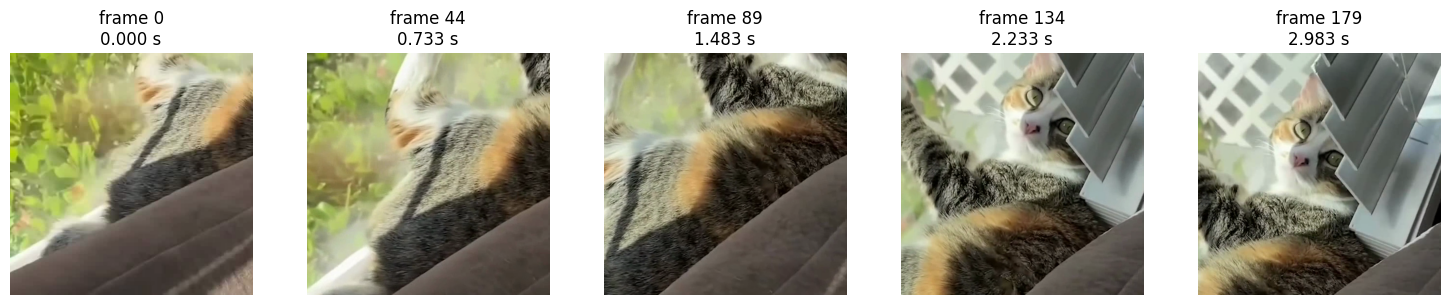

In [3]:
"""
decode_video_frames
Decodes every frame of a local video in sequential source order.

INPUT:
    - video_path: str | Path -> local movie file

OUTPUT:
    - frames_rgb: list[np.ndarray] -> all H x W x 3 uint8 RGB frames
    - source_fps: float -> decoded frame rate
    - reported_frame_count: int -> frame count reported by the video container
"""
def decode_video_frames(video_path):
    video_path = Path(video_path).expanduser().resolve()
    if not video_path.exists():
        raise FileNotFoundError(video_path)
    # end if not video_path.exists()

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open {video_path}")
    # end if not cap.isOpened()

    source_fps = float(cap.get(cv2.CAP_PROP_FPS))
    reported_frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frames_rgb = []

    try:
        while True:
            ok, frame_bgr = cap.read()
            if not ok:
                break
            # end if not ok
            frames_rgb.append(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
        # end while
    finally:
        cap.release()
    # end try

    if not frames_rgb:
        raise RuntimeError(f"No frames could be decoded from {video_path}")
    # end if not frames_rgb
    if not np.isfinite(source_fps) or source_fps <= 0:
        source_fps = 30.0
        print("Invalid FPS metadata; using 30 Hz for timestamps.")
    # end if invalid source_fps
    return frames_rgb, source_fps, reported_frame_count
# EOF


if cfg.video_path is None:
    raise ValueError("Set cfg.video_path in the configuration cell before running.")
# end if cfg.video_path

video_path = Path(cfg.video_path).expanduser().resolve()
all_frames_rgb, source_fps, reported_frame_count = decode_video_frames(video_path)
num_video_frames = len(all_frames_rgb)
source_indices = np.arange(num_video_frames)
source_times_s = source_indices / source_fps

print(f"Video: {video_path}")
print(f"Decoded frames: {num_video_frames}")
print(f"Container-reported frames: {reported_frame_count}")
print(f"Source rate: {source_fps:.3f} Hz")
print(f"Raw frame shape/dtype: {all_frames_rgb[0].shape} / {all_frames_rgb[0].dtype}")

# Display the beginning, middle, and end without changing the extraction order.
shown_indices = np.unique(
    np.linspace(0, num_video_frames - 1, min(5, num_video_frames), dtype=int)
)
fig, axes = plt.subplots(
    1, len(shown_indices), figsize=(3.0 * len(shown_indices), 3), squeeze=False,
)
for ax, frame_index in zip(axes[0], shown_indices):
    ax.imshow(all_frames_rgb[frame_index])
    ax.set_title(f"frame {frame_index}\n{source_times_s[frame_index]:.3f} s")
    ax.axis("off")
# end for frame_index
plt.tight_layout()


## 4. Preprocess every frame once

The official processor resizes, center-crops, rescales, and normalizes the RGB frames.
Chunking prevents preprocessing from creating one very large temporary array. The chunks
are concatenated on the CPU into `(batch, frames, channels, height, width)`; each 16-frame
window is moved to the model device only when it is used.


In [4]:
"""
preprocess_video_in_chunks
Applies the official V-JEPA 2 preprocessing to all frames without temporal sampling.

INPUT:
    - processor: AutoVideoProcessor -> official checkpoint video processor
    - frames_rgb: list[np.ndarray] -> decoded RGB frames in source order
    - chunk_size: int -> number of frames transformed per CPU chunk
    - dtype: torch.dtype -> stored tensor dtype

OUTPUT:
    - pixel_values: torch.Tensor -> CPU tensor B x T x C x H x W
"""
def preprocess_video_in_chunks(processor, frames_rgb, chunk_size, dtype):
    processed_chunks = []
    for chunk_start in tqdm(
            range(0, len(frames_rgb), chunk_size),
            desc="preprocessing frames",
            ):
        chunk_stop = min(chunk_start + chunk_size, len(frames_rgb))
        chunk_frames = frames_rgb[chunk_start:chunk_stop]
        chunk_pixels = processor(
            chunk_frames, return_tensors="pt",
        )["pixel_values_videos"]

        expected_chunk_frames = chunk_stop - chunk_start
        if chunk_pixels.shape[:2] != (1, expected_chunk_frames):
            raise RuntimeError(
                "The processor changed the temporal dimension: "
                f"expected (1, {expected_chunk_frames}), "
                f"got {tuple(chunk_pixels.shape[:2])}."
            )
        # end if processor changed temporal length
        processed_chunks.append(chunk_pixels.to(device="cpu", dtype=dtype))
    # end for chunk_start
    return torch.cat(processed_chunks, dim=1)
# EOF


video_processor = AutoVideoProcessor.from_pretrained(cfg.repo_url)
pixel_values_cpu = preprocess_video_in_chunks(
    video_processor,
    all_frames_rgb,
    chunk_size=cfg.preprocess_chunk_size,
    dtype=cfg.dtype,
)

if pixel_values_cpu.shape[1] != num_video_frames:
    raise RuntimeError("Preprocessing did not preserve the decoded frame count.")
# end if frame count changed

print(f"Processor size: {video_processor.size}")
print(f"Center crop: {video_processor.crop_size}")
print(f"Mean/std: {video_processor.image_mean} / {video_processor.image_std}")
print(f"Full video tensor [B,T,C,H,W]: {tuple(pixel_values_cpu.shape)}")

# The preprocessed CPU tensor is sufficient after this point.
del all_frames_rgb


preprocessing frames:   0%|          | 0/3 [00:00<?, ?it/s]

Processor size: {'shortest_edge': 292}
Center crop: {'height': 256, 'width': 256}
Mean/std: [0.485, 0.456, 0.406] / [0.229, 0.224, 0.225]
Full video tensor [B,T,C,H,W]: (1, 180, 3, 256, 256)


## 5. Explicit left padding and stride-one windows

For target frame `i`, the real portion of the window ends at `i`. When fewer than
`window_size_frames` source frames have been observed, copies of source frame 0 are
prepended. After the first full window, both boundaries move forward exactly one frame at
a time.


In [5]:
"""
sliding_window_source_indices
Builds the source-frame indices for one fixed window ending at a target frame.

INPUT:
    - right_frame_index: int -> source frame represented by the window output
    - total_frames: int -> number of decoded source frames
    - window_size: int -> fixed number of frames passed to the model

OUTPUT:
    - window_indices: np.ndarray -> source indices including repeated zeros on the left
    - num_left_padding: int -> number of repeated first-frame entries
"""
def sliding_window_source_indices(right_frame_index, total_frames, window_size):
    if not 0 <= right_frame_index < total_frames:
        raise IndexError(
            f"right_frame_index={right_frame_index} is outside [0, {total_frames})."
        )
    # end if invalid right_frame_index
    if window_size < 1:
        raise ValueError("window_size must be positive.")
    # end if invalid window_size

    first_real_index = max(0, right_frame_index - window_size + 1)
    real_indices = np.arange(first_real_index, right_frame_index + 1, dtype=int)
    num_left_padding = window_size - len(real_indices)

    # Index 0 is repeated because padding must use the video's first frame.
    left_padding_indices = np.zeros(num_left_padding, dtype=int)
    window_indices = np.concatenate([left_padding_indices, real_indices])
    return window_indices, num_left_padding
# EOF


"""
build_left_padded_window
Slices one fixed-size stride-one window and pads its left edge with the first video frame.

INPUT:
    - video_tensor: torch.Tensor -> B x T x C x H x W preprocessed full video
    - right_frame_index: int -> source frame at the right edge of this window
    - window_size: int -> fixed window length

OUTPUT:
    - window: torch.Tensor -> B x window_size x C x H x W
    - window_indices: np.ndarray -> source index at every window position
    - num_left_padding: int -> number of repeated first frames
"""
def build_left_padded_window(video_tensor, right_frame_index, window_size):
    total_frames = video_tensor.shape[1]
    window_indices, num_left_padding = sliding_window_source_indices(
        right_frame_index, total_frames, window_size,
    )

    first_real_index = int(window_indices[num_left_padding])
    real_frames = video_tensor[:, first_real_index:right_frame_index + 1]

    # Repeat the first source frame until the early window reaches its fixed length.
    left_padding = video_tensor[:, :1].repeat(
        1, num_left_padding, 1, 1, 1,
    )
    window = torch.cat([left_padding, real_frames], dim=1)

    if window.shape[1] != window_size:
        raise RuntimeError(
            f"Expected a {window_size}-frame window, got {window.shape[1]} frames."
        )
    # end if incorrect window length
    return window, window_indices, num_left_padding
# EOF


diagnostic_right_edges = sorted({
    0,
    min(1, num_video_frames - 1),
    min(cfg.window_size_frames - 1, num_video_frames - 1),
    min(cfg.window_size_frames, num_video_frames - 1),
    num_video_frames - 1,
})
for right_frame_index in diagnostic_right_edges:
    _, window_indices, num_left_padding = build_left_padded_window(
        pixel_values_cpu, right_frame_index, cfg.window_size_frames,
    )
    print(
        f"target={right_frame_index:4d}, left_pad={num_left_padding:2d}, "
        f"window={window_indices.tolist()}"
    )
# end for right_frame_index


target=   0, left_pad=15, window=[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
target=   1, left_pad=14, window=[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
target=  15, left_pad= 0, window=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
target=  16, left_pad= 0, window=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
target= 179, left_pad= 0, window=[164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179]


## 6. Load V-JEPA 2 with `vidANN` and select matching hook layers

For consistency with the project's other ViT definitions, every hook targets
`encoder.layer.{i}.mlp.fc2`. This is the second linear projection of the block MLP:

```text
norm2 → fc1 → activation → fc2 → drop_path → residual addition
                              ^
                           hook here
```

It is not the full block output and it does not include the encoder's final LayerNorm.
The same module position is selected for all 24 blocks.


In [6]:
ann = vidANN(
    model_name=cfg.model_name,
    pkg=cfg.pkg,
    img_size=cfg.image_size,
    num_frames=cfg.window_size_frames,
    architecture=cfg.architecture,
    relevant_layers=[],
    pooling=cfg.pooling,
    last_frame=cfg.last_frame,
    tubelet_size=cfg.tubelet_size,
    dtype=cfg.dtype,
    attn_implementation=cfg.attn_implementation,
    repo_url=cfg.repo_url,
    trust_remote_code=False,
    device=cfg.device,
)
model = ann.get_model()
model.eval()

target_layers = [
    f"encoder.layer.{block_index}.{cfg.hook_module}"
    for block_index in range(model.config.num_hidden_layers)
]
ann.set_relevant_layers(target_layers)

print(ann)
print(
    "Config: "
    f"frames={model.config.frames_per_clip}, crop={model.config.crop_size}, "
    f"tubelet={model.config.tubelet_size}, patch={model.config.patch_size}, "
    f"blocks={model.config.num_hidden_layers}, hidden={model.config.hidden_size}"
)
print(f"First hook: {target_layers[0]}")
print(f"Last hook:  {target_layers[-1]}")
assert model.config.crop_size == cfg.image_size
assert model.config.patch_size == cfg.patch_size
assert model.config.tubelet_size == cfg.tubelet_size


vidANN(model=vjepa2_vitl_fpc64_256, pkg=hf, architecture=transformer, pooling=mean, last_frame=True, frames=16, device=mps, img_size=256)
Config: frames=64, crop=256, tubelet=2, patch=16, blocks=24, hidden=1024
First hook: encoder.layer.0.mlp.fc2
Last hook:  encoder.layer.23.mlp.fc2


### What `vidANN` pools

The hooked transformer activation has shape:

```text
(batch, temporal tubelets × spatial patches, channels)
```

For a 16-frame V-JEPA 2 window, this is
`(batch, 8 × 16 × 16, 1024)`. `vidANN` uses the current input frame count and
`tubelet_size=2` to restore the temporal groups.

- `last_frame=True`, `pooling="mean"`: select the final tubelet's 16×16 tokens and
  spatially average them, producing `(batch, 1024)`.
- `last_frame=False`, `pooling="mean"`: average every temporal and spatial token,
  producing `(batch, 1024)`.
- `pooling=None`: retain the unpooled selected tokens.
- `pooling="all"`: flatten the selected tokens.

For a video CNN, `vidANN` instead expects `(batch, channels, time, height, width)`.
It selects the last time slice before spatial pooling when `last_frame=True`, or pools
over time and space when `last_frame=False`.


## 7. Sliding-window extraction through `vidANN`

The extraction loop now delegates feature capture and pooling to `vidANN`:

1. build one fixed window ending at the current source frame;
2. run all 16 frames through V-JEPA 2 via `ann.extract_features`;
3. capture every configured `mlp.fc2` activation with the inherited hook system;
4. let `vidANN(last_frame=True)` select and spatially pool the final tubelet;
5. stack the 24 hooked layer vectors;
6. collect one stacked result per source frame.

The returned shape is `(batch, source frames, hooked layers, channels)`.


In [7]:
"""
extract_sliding_window_features
Extracts one rightmost vidANN feature per stride-one fixed video window.

INPUT:
    - ann: vidANN -> initialized video wrapper with model and pooling configuration
    - video_tensor: torch.Tensor -> CPU tensor B x T x C x H x W
    - layer_names: list[str] -> ordered module paths captured by forward hooks
    - window_size: int -> fixed number of frames in every model call
    - desc: str -> progress-bar label

OUTPUT:
    - features: torch.Tensor -> CPU tensor B x T x layers x feature channels
"""
def extract_sliding_window_features(
        ann, video_tensor, layer_names, window_size=16,
        desc="sliding V-JEPA 2 windows",
        ):
    if window_size % ann.tubelet_size:
        raise ValueError("window_size must contain complete temporal tubelets.")
    # end if incomplete tubelet
    if not ann.last_frame:
        raise ValueError(
            "last_frame must be True to retain only the window's right edge."
        )
    # end if not ann.last_frame

    _, total_frames = video_tensor.shape[:2]
    model_parameter = next(ann.model.parameters())
    model_device = model_parameter.device
    model_dtype = model_parameter.dtype
    diagnostic_right_edges = {
        0,
        min(1, total_frames - 1),
        min(window_size - 1, total_frames - 1),
        min(window_size, total_frames - 1),
        total_frames - 1,
    }
    rightmost_features = []
    ann.create_forward_hook(layer_names=layer_names)

    try:
        with torch.inference_mode():
            for right_frame_index in tqdm(range(total_frames), desc=desc):
                # The slice ends here, so later source frames cannot enter this output.
                window_cpu, window_indices, num_left_padding = build_left_padded_window(
                    video_tensor, right_frame_index, window_size,
                )
                window = window_cpu.to(device=model_device, dtype=model_dtype)

                # vidANN runs the model, captures the hooks, selects the last temporal
                # tubelet, and applies the configured spatial pooling.
                hooked_features = ann.extract_features(
                    {
                        "pixel_values_videos": window,
                        "skip_predictor": True,
                    },
                    method="hook",
                )

                layer_features = []
                for layer_name in layer_names:
                    features = hooked_features.get(layer_name)
                    if features is None:
                        raise RuntimeError(
                            f"The forward hook did not capture {layer_name}."
                        )
                    # end if missing hook output
                    if features.ndim != 2:
                        raise RuntimeError(
                            f"Expected pooled B x channels features for {layer_name}, "
                            f"got {tuple(features.shape)}."
                        )
                    # end if unexpected pooled shape
                    layer_features.append(features)
                # end for layer_name

                # B x hooked transformer layers x pooled feature channels.
                rightmost_feature = torch.stack(layer_features, dim=1)
                rightmost_features.append(
                    rightmost_feature.detach().float().cpu()
                )

                if right_frame_index in diagnostic_right_edges:
                    print(
                        f"target={right_frame_index:4d}, "
                        f"left_pad={num_left_padding:2d}, "
                        f"indices={window_indices.tolist()}, "
                        f"kept={tuple(rightmost_feature.shape)}"
                    )
                # end if diagnostic window

                del hooked_features, layer_features, rightmost_feature, window
            # end for right_frame_index
        # end with inference_mode
    finally:
        ann.clear_hooks()
    # end try

    return torch.stack(rightmost_features, dim=1)
# EOF


sliding_features_batched = extract_sliding_window_features(
    ann=ann,
    video_tensor=pixel_values_cpu,
    layer_names=target_layers,
    window_size=cfg.window_size_frames,
)

# Remove the singleton batch dimension for this one-video tutorial.
video_feature_sequence = sliding_features_batched[0]

print(
    "Batched sequence [B,source frames,layers,channels]: "
    f"{tuple(sliding_features_batched.shape)}"
)
print(
    "Whole-video sequence [source frames,layers,channels]: "
    f"{tuple(video_feature_sequence.shape)}"
)
print("First retained vector:", video_feature_sequence[0, 0, :8].numpy())


sliding V-JEPA 2 windows:   0%|          | 0/180 [00:00<?, ?it/s]

target=   0, left_pad=15, indices=[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], kept=(1, 24, 1024)
target=   1, left_pad=14, indices=[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1], kept=(1, 24, 1024)
target=  15, left_pad= 0, indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15], kept=(1, 24, 1024)
target=  16, left_pad= 0, indices=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16], kept=(1, 24, 1024)
target= 179, left_pad= 0, indices=[164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179], kept=(1, 24, 1024)
Batched sequence [B,source frames,layers,channels]: (1, 180, 24, 1024)
Whole-video sequence [source frames,layers,channels]: (180, 24, 1024)
First retained vector: [ 0.10833742 -0.43687046 -0.1321199   0.16696787  0.5964597  -0.03229749
 -0.7501373  -0.01901935]


## 8. Alignment checks

These checks verify the three key invariants without making another model pass:

- the output length equals the decoded source-frame count;
- every window's right edge equals the output's source-frame index;
- after the first complete window, consecutive windows advance by exactly one frame.


In [8]:
if video_feature_sequence.shape[0] != num_video_frames:
    raise RuntimeError(
        f"Expected {num_video_frames} output entries, "
        f"got {video_feature_sequence.shape[0]}."
    )
# end if output length mismatch

first_indices, first_padding = sliding_window_source_indices(
    0, num_video_frames, cfg.window_size_frames,
)
if first_padding != cfg.window_size_frames - 1:
    raise RuntimeError("The first window does not contain the expected left padding.")
# end if first padding mismatch
if not np.all(first_indices == 0):
    raise RuntimeError("The first window was not padded exclusively with frame 0.")
# end if first window indices mismatch

for right_frame_index in range(num_video_frames):
    window_indices, _ = sliding_window_source_indices(
        right_frame_index, num_video_frames, cfg.window_size_frames,
    )
    if window_indices[-1] != right_frame_index:
        raise RuntimeError(
            f"Window {right_frame_index} ends at {window_indices[-1]}."
        )
    # end if incorrect right edge

    if right_frame_index >= cfg.window_size_frames:
        previous_indices, _ = sliding_window_source_indices(
            right_frame_index - 1, num_video_frames, cfg.window_size_frames,
        )
        if not np.array_equal(window_indices[:-1], previous_indices[1:]):
            raise RuntimeError(
                f"Windows {right_frame_index - 1} and {right_frame_index} "
                "do not differ by a one-frame slide."
            )
        # end if stride mismatch
    # end if full-window regime
# end for right_frame_index

print("PASS: one output feature entry was collected for every decoded frame.")
print("PASS: the first window repeats source frame 0 on the left.")
print("PASS: complete windows slide forward with stride 1.")
print(
    f"Feature timestamps run from {source_times_s[0]:.4f} s "
    f"to {source_times_s[-1]:.4f} s at {source_fps:.3f} Hz."
)


PASS: one output feature entry was collected for every decoded frame.
PASS: the first window repeats source frame 0 on the left.
PASS: complete windows slide forward with stride 1.
Feature timestamps run from 0.0000 s to 2.9833 s at 60.000 Hz.


## Interpretation of the final tensor

With `pooling="mean"`, `video_feature_sequence` has shape:

```text
(decoded source frames, 24 hooked MLP projections, 1024 channels)
```

- Entry `i` comes from a 16-frame window whose right edge is source frame `i`.
- Early windows are padded only on the left by repeating source frame 0.
- Once 16 real frames are available, the window advances with stride 1.
- Every layer axis position hooks the same `mlp.fc2` sublayer in its corresponding block.
- `vidANN(last_frame=True)` selects the final temporal tubelet and pools its 16×16 spatial
  patch tokens; `last_frame=False` would pool the complete window instead.
- Since the checkpoint uses two-frame tubelets, the retained position summarizes the
  window's final two raw frames rather than an independent single-frame token.
- The encoder is bidirectional within each 16-frame window, but no source frame later than
  `i` is used for output entry `i`.
